### test

In [ ]:
class SwarmState(TypedDict):
    messages: list[any]
    user_query: str
    plan: list[str]
    query_db: any
    relevant_docs: list[dict]


In [5]:
from langgraph.prebuilt import create_react_agent

In [8]:
from tavily import TavilyClient
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
response = tavily_client.search("Who is Leo Messi?")

In [9]:
response

{'query': 'Who is Leo Messi?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Lionel_Messi',
   'title': 'Lionel Messi - Wikipedia',
   'content': "An Argentine international, Messi is the national team's all-time leading goalscorer and most-capped player. Several years after his senior debut in 2005, he",
   'score': 0.86358756,
   'raw_content': None},
  {'url': 'https://www.biography.com/athletes/lionel-messi',
   'title': 'Lionel Messi: Biography, Soccer Player, Inter Miami CF, Athlete',
   'content': 'Lionel Messi, a forward for Inter Miami CF, is one of the world’s greatest soccer players and helped the Argentina national team win its third FIFA World Cup in 2022. Messi, now playing for Inter Miami CF of the MLS, helped his home country win soccer’s biggest event for the first time since 1986, scoring two goals in the final and leading Argentina to a 4-2 win over Kylian Mbappé and France on penalties. Lionel Messi

In [10]:
def search_internet(query: str) -> str:
    """
    Searches the internet for the given query.
    Arguments:
        query: The query to search for.
    Returns:
        A dicitonary containing the search results.

    """

    response = tavily_client.search(query)
    return response

def sum(a: int, b: int) -> int:
    """
    Calculates the sum of two integers.
    Arguments:
        a: The first integer.
        b: The second integer.
    Returns:
        The sum of the two integers.
    """
    return a + b

In [13]:
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_react_agent(
    model=llm,
    tools=[get_weather],
    prompt="You are a helpful assistant"
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='f8dd3e83-eb6a-4cfd-b003-6e351b485e43'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for the weather in SF. I need to figure out which function to use. The available tool is get_weather, which requires a city parameter. SF is a common abbreviation for San Francisco. So I should call get_weather with the city set to San Francisco. Let me make sure there's no other possible interpretation, but SF is widely known as San Francisco. Alright, I'll proceed with that.\n", 'tool_calls': [{'id': 'myq0vhaa5', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 158, 'total_tokens': 269, 'completion_time': 0.218438009, 'prompt_time': 0.006307211, 'queue_time': 0.213958486, 'total_time': 0.22474522}, 'model_name': 'qwen/

### imports

In [1]:
!pip install -q langchain-groq langgraph pymupdf langchain_community langchain_chroma "unstructured[pdf]"
!apt install poppler-utils tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [93]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from google.colab import userdata
import os
from uuid import uuid4
from copy import deepcopy

from unstructured.documents.elements import NarrativeText, Title, Image, Table
import fitz
import re
from unstructured.partition.pdf import partition_pdf
from pypdf import PdfWriter, PdfReader


os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_summariser = ChatGroq(model="llama-3.1-8b-instant")
llm_image_summariser = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")


from langchain.vectorstores import Chroma
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.embeddings import HuggingFaceEmbeddings


from typing import Annotated, Literal, List
from typing_extensions import TypedDict
from operator import add
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

import json
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.tools import InjectedToolArg, tool, InjectedToolCallId
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.runnables.config import RunnableConfig

In [3]:
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "rag_swarm"

### docstore code


In [40]:
def get_summary(text):
    messages = [SystemMessage("""
    Your job is to summarize the given raw text. Chunks of raw text are given to you and you have to analyze properly what all is contained in them.
    Pay special attention to table captions, image captions and formulas and include them in your summaries.
    You can skip the factual numeric details but you must tell what all is contained in the given chunk of raw text.

    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the raw text: {text}"))
    res = llm_summariser.invoke(messages)

    return res.content

def get_image_summary(image_data):
    messages = [SystemMessage("""
    Your job is to summarize the given image.
    If the image is graph, extract relevant details like graph title, axis labels, maximum values etc.
    If the image is a diagram or illustration extract important components and make proper analysis in them.
    Include keywords in your summary that will help map the summary easily to the image
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(content=[
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{image_data}"},
        }
    ]))
    res = llm_image_summariser.invoke(messages)

    return res.content

def get_table_summary(table_data):
    messages = [SystemMessage("""
    Your job is to summarize the given table. The table is in HTML format. Describe the table properly, include keywords that help in telling what all data is contained in the table.
    Make sure to include the names of column headings or row headings as necessary. Properly analyze the table and return a dense yet concise summary.
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the table in HTML format: {table_data}"))
    res = llm_summariser.invoke(messages)

    return res.content

In [41]:
class Docstore():
    def __init__(self, pdf_path):
        self.pdf_path = pdf_path


    def get_doc_hierarchy(self):

        def find_toc_pages(doc, search_limit=20):
            toc_pages = []
            for i in range(min(len(doc), search_limit)):
                page = doc[i]
                text = page.get_text("text", sort=True).lower()
                if "contents" in text or "table of contents" in text:
                    toc_pages.append(i)
            return toc_pages

        def toc_raw_to_hierarchy(toc_raw):
            messages = [SystemMessage("""
                You are a document hierarchy generator. Your task is to generate a python dictionary.
                You are given the raw text on the table of contents page of a document.
                analyze it properly and structure it into a neat json object.
                The document hierarchy is only needed till depth level 2. the schema of the json object is as follows
                {
                    "section_name": str
                    "section_children": list[str]
                }
                You must follow this schema.
                YOur output should be json object and it will be evaluated as it is so do not give boilerplate text or backticks
                """)]
            messages.append(HumanMessage("here is the raw text on the table of contents page of the document"))
            messages.append(HumanMessage(toc_raw))

            res = llm.with_structured_output(method="json_mode").invoke(messages)
            return res

        def toc_to_hierarchy(toc):
            hierarchy = []
            for i in range(len(toc)):
                if toc[i][0] == 1:
                    new_section = {
                        "section_name": toc[i][1],
                        "section_children": []
                    }
                    new_section_children = []
                    for j in range(i+1, len(toc)):
                        if toc[j][0] == 2:
                            new_section_children.append(toc[j][1])
                        elif toc[j][0] == 1:
                            break
                    new_section["section_children"] = new_section_children
                    hierarchy.append(new_section)
            return hierarchy

        doc = fitz.open(self.pdf_path)
        toc = doc.get_toc()
        toc_pages = find_toc_pages(doc)
        if toc:
            return toc_to_hierarchy(toc), toc_pages


        if toc_pages:
            toc_raw = ""
            for i in toc_pages:
                toc_raw += doc[i].get_text("text")
            return toc_raw_to_hierarchy(toc_raw), toc_pages

        return None

    def create_headings_store(self):

        self.low_res_elements = partition_pdf(
            filename="report.pdf",
            strategy="fast"
        )
        self.doc_hierarchy, self.toc_pages = self.get_doc_hierarchy()

        doc_hierarchy = deepcopy(self.doc_hierarchy)
        current_section_idx = 0
        current_section_chunks = []

        if self.toc_pages:
            last_toc_page = self.toc_pages[-1]
            split_idx = next(
                (i for i, x in enumerate(elements) if x.metadata.page_number == last_toc_page + 2),
                None
            )
            elements = elements[split_idx:]

        next_section_name = (
            doc_hierarchy[current_section_idx + 1]["section_name"]
            if current_section_idx + 1 < len(doc_hierarchy)
            else None
        )

        for e in self.low_res_elements:
            if next_section_name and isinstance(e, Title) and next_section_name in e.text:
                doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks
                current_section_chunks = [e]
                current_section_idx += 1
                next_section_name = (
                    doc_hierarchy[current_section_idx + 1]["section_name"]
                    if current_section_idx + 1 < len(doc_hierarchy)
                    else None
                )
            else:
                current_section_chunks.append(e)

        doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks


        leaf_sections = []
        for section in doc_hierarchy:
            if len(section["section_children"]) == 0:
                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_name"],
                    "section_chunks": section["section_chunks"]
                })
            else:
                current_subsec_chunks = []
                split_idx = 0
                for i in range(len(section["section_chunks"])):
                    e = section["section_chunks"][i]
                    if isinstance(e, Title) and section["section_children"][0] in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_name"],
                            "section_chunks": current_subsec_chunks
                        })
                        split_idx = i
                        break
                    else:
                        current_subsec_chunks.append(e)

                section["section_chunks"] = section["section_chunks"][split_idx:]
                current_subsec_idx = 0
                current_subsec_chunks = []
                next_subsec_name = (
                    section["section_children"][current_subsec_idx + 1]
                    if current_subsec_idx + 1 < len(section["section_children"])
                    else None
                )
                for e in section["section_chunks"]:
                    if next_subsec_name and isinstance(e, Title) and next_subsec_name in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_children"][current_subsec_idx],
                            "section_chunks": current_subsec_chunks
                        })

                        current_subsec_chunks = [e]
                        current_subsec_idx += 1
                        next_subsec_name = (
                            section["section_children"][current_subsec_idx + 1]
                            if current_subsec_idx + 1 < len(section["section_children"])
                            else None
                        )
                    else:
                        current_subsec_chunks.append(e)

                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_children"][current_subsec_idx],
                    "section_chunks": current_subsec_chunks
                })

        self.leaf_sections = leaf_sections

        text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)

        summaries = {}

        for sec in leaf_sections:
            sec_text = []
            for sec_chunk in sec["section_chunks"]:
                if isinstance(sec_chunk, NarrativeText):
                    sec_text.append(sec_chunk.text)
            if len(sec_text) == 0:
                continue
            raw_sec_text = "\n".join(sec_text)
            sec_text_chunks = text_splitter.split_text(raw_sec_text)
            sec_summaries = []
            for sec_chunk in sec_text_chunks:
                sec_summaries.append(get_summary(sec_chunk))

            if len(sec_summaries) > 1:
                sec_summary = get_summary("\n".join(sec_summaries))
            else:
                sec_summary = sec_summaries[0]

            summaries[sec["section_id"]] = sec_summary

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

        heading_store = Chroma(collection_name="heading_store", embedding_function=embeddings)

        # The storage layer for the parent documents
        store = InMemoryStore()
        id_key = "section_id"

        # The retriever (empty to start)
        heading_retriever = MultiVectorRetriever(
            vectorstore=heading_store,
            docstore=store,
            id_key=id_key,
        )
        heading_retriever.vectorstore.add_documents([
            Document(
                page_content=sec_sum,
                metadata={id_key: sec_id}
            )
            for sec_id, sec_sum in summaries.items()
        ])
        heading_retriever.docstore.mset([
            (sec["section_id"], sec)
            for sec in leaf_sections
        ])
        self.heading_retriever = heading_retriever
        self.page_cache = {}
        return heading_retriever

    def create_query_retriever(self, relevant_page_numbers):
        if not hasattr(self, "page_cache"):
            self.page_cache = {}

        pages_not_cached = []
        for page_number in relevant_page_numbers:
            if page_number not in self.page_cache:
                pages_not_cached.append(page_number)
        if len(pages_not_cached) != 0:
            writer = PdfWriter()
            input_pdf  = PdfReader("report.pdf")
            for i in pages_not_cached:
                writer.add_page(input_pdf.pages[i-1])

            batch_filename = 'elements.pdf'
            with open(batch_filename, 'wb') as output_file:
                writer.write(output_file)

            high_res_pages = partition_pdf(
                filename="elements.pdf",
                strategy="hi_res",
                extract_image_block_types=["Image"],
                extract_image_block_to_payload=True,
                infer_table_structure=True
            )

            newly_cached_pages = [[] for _ in pages_not_cached]
            for c in high_res_pages:
                newly_cached_pages[c.metadata.page_number - 1].append(c)

            for i in range(len(newly_cached_pages)):
                image_store = []
                table_store = []
                raw_text_store = []
                for c in newly_cached_pages[i]:
                    if isinstance(c, Image):
                        image_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "image",
                            "image_data": c.metadata.image_base64,
                            "image_summary": get_image_summary(c.metadata.image_base64)
                        })
                    elif isinstance(c, Table):
                        table_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "table",
                            "table_data": c.metadata.text_as_html,
                            "table_summary": get_table_summary(c.metadata.text_as_html)
                        })
                    else:
                        raw_text_store.append(c.text)


                    raw_text = "\n".join(raw_text_store)
                    text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)
                    raw_text_store = text_splitter.split_text(raw_text)
                    text_store = [{
                            "doc_id": str(uuid4()),
                            "doc_type": "text",
                            "text_data": t
                        } for t in raw_text_store]

                    new_cache = {
                        "high_res_chunks": newly_cached_pages[i],
                        "image_store": image_store,
                        "table_store": table_store,
                        "text_store": text_store
                    }
                self.page_cache[pages_not_cached[i]] = new_cache

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
        query_store = Chroma(collection_name="query_store", embedding_function=embeddings)
        query_doc_store = InMemoryStore()
        id_key="doc_id"

        query_retriever = MultiVectorRetriever(
            vectorstore=query_store,
            docstore=query_doc_store,
            id_key=id_key,
        )
        image_for_query = []
        table_for_query = []
        text_for_query = []

        for page in relevant_page_numbers:
            image_for_query += self.page_cache[page]["image_store"]
            table_for_query += self.page_cache[page]["table_store"]
            text_for_query += self.page_cache[page]["text_store"]

        if image_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=image["image_summary"],
                    metadata={id_key: image["doc_id"], "doc_type": "image"}
                )
                for image in image_for_query
            ])
            query_retriever.docstore.mset([
                (image["doc_id"], image)
                for image in image_for_query
            ])

        if table_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=table["table_summary"],
                    metadata={id_key: table["doc_id"], "doc_type": "table"}
                )
                for table in table_for_query
            ])
            query_retriever.docstore.mset([
                (table["doc_id"], table)
                for table in table_for_query
            ])

        if text_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=text["text_data"],
                    metadata={id_key: text["doc_id"], "doc_type": "text"}
                )
                for text in text_for_query
            ])
            query_retriever.docstore.mset([
                (text["doc_id"], text)
                for text in text_for_query
            ])

        return query_retriever

### rag agent

In [7]:
EVALUATOR_PROMPT ="""

You are an evaluator LLM, your job is to verify and score the documents retrieved from a corpus for a given query.

You are given the following information:
1. The hierarchy of the data corpus.
2. A full history of user queries that have been asked on the data. They may be explicit or it may be indirect and multi-hop requiring several documents to be extracted.
3. The summary of all the chunks of text, image or table that have been retrieved for the given query. This needs to be used to answer the user query.
4. The exact sections of hierarchy from where these chunks are extracted.
5. Your previous logs, if there are subsequent runs.

Your job is to judge several things:
1. Are the retrieved documents fit and enough for answering the query? Yes or No.
2. A relevancy score for the extracted documents with reference to the user query, between 0 and 1. Only decimal numbers (like 0.12, 0.4, 0.9) are allowed, don't use strings like "0. nine".
3. If the retrieved documents are not enough (i.e. the answer of first question is no) then what is the reason out of these 3 possibilities ONLY
    a. The retrieval is being done from the correct section of the document, but more data from the section is needed.
    b. The retrieval is being done from a completely irrelevant section of the document and the corpora needs to be visited again to find the most valuable sections.
    c. The given user query cannot be answered given this hierarchy of the data, meaning the answer does not exist in the given data.
4. If you choose a or b as the possibility. Then, also suggest a new better prompt which may retrieve more relevant chunks or sections from the given data.
5. A concise log of action that has been performed in this run. Tell what exactly happened, if retrieval was not sufficient, then why and what better action was taken. Not more than 2 lines.

IMPORTANT POINTS:
- Give utmost priority to "doc_type" field of extracted documents.
- If the query is such that it requires numeric evidence but the "doc_type" is "text" and the text is not sufficient to answer. Ask for re-retrieval of a "table"
- If the query is such that it requires graphs, charts or figures but "doc_type" "image" is not present, ask for re-retrieval of "image"
- If the query asks for numerics and the "doc_type" has "table". Then, ACCEPT the retrieval, the docs are fit.

OUTPUT FORMAT:
You have to answer in a structured format with the attached schema only, follow exact variable names and output types. If a field is empty or has value null, drop it and don't include in output.
"""

EVALUATOR_SCHEMA = {
  "title": "EVALUATOR_SCHEMA",
  "description": "A schema to validate the output of an evaluation.",
  "type": "object",
  "properties": {
    "docs_fit": {
      "description": "A string, either 'yes' or 'no'.",
      "type": "string",
      "enum": [
        "yes",
        "no"
      ]
    },
    "relevancy_score": {
      "description": "A floating point number between 0 and 1.",
      "type": "number",
      "minimum": 0,
      "maximum": 1
    },
    "reason_for_no": {
      "description": "The reason for a 'no' fit, can be 'a', 'b', or 'c'.",
      "type": "string",
      "enum": [
        "a",
        "b",
        "c"
      ]
    },
    "better_prompt": {
      "description": "A suggestion for a better prompt to query the data, if the retrieved data is not enough.",
      "type": "string"
    },
    "log": {
      "description": "A one-line log of the action performed in this run.",
      "type": "string"
    }
  },
  "required": [
    "docs_fit",
    "relevancy_score",
    "log"
  ]
}
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_evaluator = llm.with_structured_output(EVALUATOR_SCHEMA)

In [8]:
class RagAgentState(TypedDict):
    user_query: Annotated[list[str], add]
    query_db: any
    sections_extracted: list[str]
    extracted_docs: any
    latest_evaluation: dict
    evaluator_logs: Annotated[list[str], add]
    agent_logs: list[dict]

In [9]:
def get_query_db(state, config):
    docstore = config["configurable"]["docstore"]
    relevant_sections = docstore.heading_retriever.invoke(state["user_query"][-1])
    relevant_sections_names = [sec["section_name"] for sec in relevant_sections]

    relevant_page_numbers = set()
    for doc in relevant_sections:
        for c in doc["section_chunks"]:
            relevant_page_numbers.add(c.metadata.page_number)

    query_db = docstore.create_query_retriever(relevant_page_numbers)

    return {"query_db": query_db, "sections_extracted": relevant_sections_names}

def get_docs(state):
    docs = state["query_db"].get_relevant_documents(state["user_query"][-1])

    return {"extracted_docs": docs}

def evaluator(state):
    docstore = config["configurable"]["docstore"]
    messages = [SystemMessage(EVALUATOR_PROMPT)]

    extracted_doc_summaries = []
    for doc in state["extracted_docs"]:
        if doc["doc_type"] == "image":
            extracted_doc_summaries.append({"doc_type": "image", "image_summary": doc["image_summary"]})
        elif doc["doc_type"] == "table":
            extracted_doc_summaries.append({"doc_type": "table", "table_data": doc["table_data"]})
        else:
            extracted_doc_summaries.append({"doc_type": "text", "text_content": doc["text_data"]})

    messages.append(HumanMessage(content=f"""
        This is the hierarchy of the data corpus:
        {json.dumps(docstore.doc_hierarchy, indent=4)}
        This is the history of user_queries on the data:
        {json.dumps(state["user_query"], indent=4)}
        This is the summary of all the chunks of text, image or table that have been retrieved for the given query:
        {json.dumps(extracted_doc_summaries, indent=4)}
        The exact section of hierarchy from where they were extracted
        {json.dumps(state["sections_extracted"], indent=4)}
        This is your previous logs, if there are subsequent runs:
        {json.dumps(state["evaluator_logs"], indent=4)}
    """))

    evaluation = llm_evaluator.invoke(messages)
    return_dict = {
        "latest_evaluation": evaluation,
        "evaluator_logs": [evaluation["log"]]
    }

    if evaluation.get("better_prompt"):
        return_dict["user_query"] = [evaluation["better_prompt"]]
    if evaluation.get("docs_fit") == "no":
        if evaluation.get("reason_for_no") == "c":
            return_dict["extracted_docs"] = None

    return return_dict

def decide_next_rag(state) -> Literal["get_query_db", "get_docs", END]:
    if state["latest_evaluation"]["docs_fit"] == "no":
        if state["latest_evaluation"]["reason_for_no"] == "a":
            return "get_docs"
        elif state["latest_evaluation"]["reason_for_no"] == "b":
            return "get_query_db"
        elif state["latest_evaluation"]["reason_for_no"] == "c":
            return END
    else:
        return END

def decide_next_agent_rag(state):
    return None

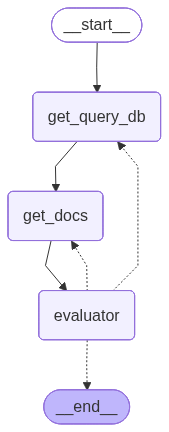

In [10]:
rag_agent_builder = StateGraph(RagAgentState)

rag_agent_builder.add_node("get_query_db", get_query_db)
rag_agent_builder.add_node("get_docs", get_docs)
rag_agent_builder.add_node("evaluator", evaluator)

rag_agent_builder.add_edge(START, "get_query_db")
rag_agent_builder.add_edge("get_query_db", "get_docs")
rag_agent_builder.add_edge("get_docs", "evaluator")
rag_agent_builder.add_conditional_edges("evaluator", decide_next_rag)

rag_agent = rag_agent_builder.compile()
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [43]:
docstore = Docstore("report.pdf")
docstore.create_headings_store()

/tmp/ipython-input-2522326861.py:193: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipython-input-2522326861.py:195: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  heading_store = Chroma(collection_name="heading_store", embedding_function=embeddings)


MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7b43698e6030>, docstore=<langchain_core.stores.InMemoryStore object at 0x7b43652bfb90>, id_key='section_id', search_kwargs={})

In [44]:
query = "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?"

In [161]:
config = {
            "configurable": {
                "docstore": docstore
            }
        }
res = rag_agent.invoke(
    {
        "user_query": [query],
        "evaluator_logs": [],
        "agent_logs": []
    },
    config=config
)

In [162]:
res["extracted_docs"]

[{'doc_id': 'adbab5e8-5e5f-42a6-8a2d-f5ecf2d3a4c8',
  'doc_type': 'table',
  'table_data': '<table><thead><tr><th>Model</th><th>EN-DE</th><th>BLEU EN-FR</th><th>Training EN-DE</th><th>Cost (FLOPs) EN-FR</th></tr></thead><tbody><tr><td colspan="5">ByteNet [18] 23.75</td></tr><tr><td>Deep-Att + PosUnk</td><td></td><td>39.2</td><td></td><td>1.0 - 107°</td></tr><tr><td>GNMT + RL 8]</td><td>24.6</td><td>39.92</td><td>2.3-10!9</td><td>1.4. 1070</td></tr><tr><td>ConvS28S [9]</td><td>25.16</td><td>40.46</td><td>9.6-10\'%</td><td>1.5-1070</td></tr><tr><td>MoE</td><td>26.03</td><td>40.56</td><td>2.0-10\'9</td><td>1.2. 107°</td></tr><tr><td>Deep-Att + PosUnk Ensemble</td><td></td><td>40.4</td><td></td><td>8.0 - 107°</td></tr><tr><td>GNMT + RL Ensemble (33</td><td>26.30</td><td>41.16</td><td>1.8-1079</td><td>1.1- 1074</td></tr><tr><td>ConvS2S Ensemble [9]</td><td>26.36</td><td>41.29</td><td>7.7-10\'9</td><td>1.2.10?!</td></tr><tr><td>Transformer (base model)</td><td>27.3</td><td>38.1</td><td>3.3 -

In [163]:
res["evaluator_logs"]

['Text retrieved is relevant but lacks numeric table; request table data from correct section.',
 'Table retrieved from Machine Translation section provides training cost data, sufficient for the query.']

### Plan and Reasoning agent

In [4]:
PLANREASON_PROMPT ="""
    You are the planning, reasoning and supervisor agent in a RAG based QA application.
    You are given the user's question and your job is to think of the valid next steps and decide which agent you need to handoff the task to. You act like the brain behind solving the given task.
    The question can be very complex requiring multiple retrieval steps, code execution, reasoning abilities and web searches. Your job is to properly reason out the problem using available tools.
    After reasoning and using the tools, you have to give the output and tell your reasoning, the next agent that needs to be called in order to solve the user's question and the data you would like to pass on to that agent.

    You are given the following information:
    - The original user query
    - The crafted plan (if there is any plan until now)
    - Chat history of all the agents until now. You can use it to figure out what all has been done up until now and what the next steps are.

    Available Tools:
    - plan_tool: Given a user query, it crafts a plan to address that query. The output is a ordered list of strings that defines the plan.
    - websearch_tool: Given a search string, it searches the web for it and returns the topmost results.

    Available Agents:
    - InfoAgent: You can give this agent a simple and context-rich query and it will retrieve the part of document (text chunk, table or image) is requ
    - MathCodingAgent: You can give this agent a mathematical problem and the data to solve that problem, it will write the code to solve it and execute that code without errors and return the final answers
    - SummarizerAgent: After all the required retrieval and calculations are done, this agent can be called and to summarize what all happened and finally give the user the answer to their query.

    Approach:
    - As soon as you receive the user's query and if no plan has been crafted until now i.e the plan array is empty, use the plan tool to create the plan.
    - At every step, recognize what all has been done up until now and where we stand in the proposed plan, carefully reason and when you think it's time to call another agent, you can do that by using the handoff tool
    - for the InfoAgent, the "destination" would be "InfoAgent"
    - for the MathCodingAgent, the "destination" would be "MathCodingAgent"
    - for the SummarizerAgent, the "destination" would be "SummarizerAgent"

    Output Format:
    You have to answer in a structured format with the attached schema only, follow exact variable names and output types. If a field is empty or has value null, drop it and don't include in output.
    You have to give three strings as output:
    - "reasoning": a short yet descriptive log of all of your reasoning, including all the tool calls you made and things you reasoned out and finally why you decided to handoff.
    - "destination": the name of the agent you want to handoff the task to.
    - "agent_args": the arguments to pass to the agent.
        - If you are calling the InfoAgent, pass a query which it can extract documents for
        - If you are calling the MathCodingAgent, pass a mathematical problem and the data to solve that problem.
        - If you are calling the SummarizerAgent, pass None

"""

PLANREASON_SCHEMA = {
  "title": "PLANREASON_SCHEMA",
  "description": "A schema to validate the output of PlanReasonAgent",
  "type": "object",
  "properties": {
    "reasoning": {
      "description": "a short yet descriptive log of all of your reasoning",
      "type": "string"
    },
    "destination": {
      "description": "the name of the agent you want to handoff the task to.",
      "type": "string",
      "enum": [
          "InfoAgent",
          "MathCodingAgent",
          "SummarizerAgent"
      ]
    },
    "agent_args": {
      "description": "the arguments to pass to the agent.",
      "type": "string"
    }
  },
  "required": [
    "reasoning",
    "destination",
    "agent_args"
  ]
}
llm = ChatGroq(model="openai/gpt-oss-120b")

In [5]:
PLAN_PROMPT = """
You are a planning agent in a RAG based QA app.

You are given the following information:
1. The hierarchy of the document from which text, tables and images can be retrieved.
2. The description of all the tools and agents that can be called, what they do and how they respond.
2. The user query. The final thing which needs to be answered.

Your goal:
You have to create a plan for answering the given query. Parse the user’s question carefully. Identify what information is needed to answer it fully.
Determine whether the question requires document retrieval, external web search, data computation, code execution, or just summarisation and which tool is the best for it.
Break down the query into simpler subqueries or tasks. Decide what agents to use and in what order.

Communication Style:
Be explicit in your instructions to other agents. Clearly specify the goal and constraints.

Available Tools / Agents:
- Information Retriever Agent: You can give this agent a simple and context-rich query and it will retrieve the part of document (text chunk, table or image) is requ
- Math and Coding Agent: You can give this agent a mathematical problem and the data to solve that problem, it will write the code to solve it and execute that code without errors and return the final answers
- Summarizer Agent: After all the required retrieval and calculations are done, this agent can be called and to summarize what all happened and finally give the user the answer to their query.

Output Format:
You have to respond in a structured format. Your plan should be a list of strings which is carefully ordered and concise enough to be easily readable.
"""

PLAN_SCHEMA = {
  "title": "PLANREASON_SCHEMA",
  "description": "A schema to validate the output of planning agent",
  "type": "object",
  "properties": {
      "plan": {
          "description": "A list of strings that defines the plan, is carefully ordered and concise enough to be easily readable.",
          "type": "array",
          "items": {
              "type": "string"
          }
      }
  },
  "required": [
      "plan"
  ]
}
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_plan = llm.with_structured_output(PLAN_SCHEMA)

injecting tool args at runtime from config:
https://langchain-ai.github.io/langgraph/how-tos/tool-calling/#configuration

tools_condition doc
https://langchain-ai.github.io/langgraph/reference/agents/?h=toolnode#langgraph.prebuilt.tool_node.tools_condition

In [94]:
@tool
def plan_tool(
    user_query: Annotated[str, "the user query for which plan needs to be created"],
    config: RunnableConfig,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """
    This is the plan tool. Given a user query, it crafts a plan to address that query. The output is a ordered list of strings that defines the plan.
    """
    doc_hierarchy = json.dumps(config.get("configurable", {})["docstore"].doc_hierarchy, indent=4)
    messages = [SystemMessage(PLAN_PROMPT)]
    messages.append(HumanMessage(content=f"""
        Document Hierarchy: {doc_hierarchy}
        User Query: {user_query}
    """))

    plan = llm_plan.invoke(messages)
    return Command(update={
        "planreason_history": [ToolMessage("Success", tool_call_id=tool_call_id)],
        "plan": plan["plan"]
    })

In [95]:
class PlanReasonAgentState(TypedDict):
    original_user_query: str
    chat_history: list[dict]
    planreason_history: Annotated[list[AnyMessage], add]
    plan: list[str]

In [102]:
planreason_tools = [plan_tool, PLANREASON_SCHEMA]
llm_planreason = llm.bind_tools(planreason_tools, parallel_tool_calls=False)
def planreason_assistant(state):
    messages = [SystemMessage(PLANREASON_PROMPT)]
    messages.append(HumanMessage(f"""
    The original user query: {state["original_user_query"]}
    The crafted plan (if there is any plan until now): {json.dumps(state.get("plan"), indent=4)}
    Chat history of all the agents: {json.dumps(state.get("chat_history"), indent=4)}
    """))
    res = llm_planreason.invoke(messages)

    return {"planreason_history": [res]}

In [ ]:
planreason_agent_builder = StateGraph(PlanReasonAgentState)

planreason_agent_builder.add_node("planreason_assistant", planreason_assistant)
planreason_agent_builder.add_node("tools", ToolNode(planreason_tools, messages_key="planreason_history"))

def tool_router(state) -> Literal["tools", "__end__"]:
    return tools_condition(state, messages_key="planreason_history")


planreason_agent_builder.add_edge(START, "planreason_assistant")
planreason_agent_builder.add_conditional_edges("planreason_assistant", tool_router)
planreason_agent_builder.add_edge("tools", "planreason_assistant")

planreason_agent = planreason_agent_builder.compile()
display(Image(planreason_agent.get_graph().draw_mermaid_png()))

In [101]:
config = {
            "configurable": {
                "docstore": docstore
            }
        }

res = planreason_agent.invoke({
    "original_user_query": "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?",
    "chat_history": [],
    "planreason_history": [],
    "plan": []
}, config=config)

BadRequestError: Error code: 400 - {'error': {'message': "Tool call validation failed: tool call validation failed: attempted to call tool 'json' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "json", "arguments": {\n  "reasoning": "A plan has already been generated with four steps. No retrieval or computation has been performed yet. According to the plan, the first action is to retrieve the training cost details for the transformer model from the \'Hardware and Schedule\' subsection. I will hand off to the InfoAgent with a focused query to extract that information.",\n  "destination": "InfoAgent",\n  "agent_args": "Transformer model training cost hardware schedule"\n}}'}}

In [76]:
tn = ToolNode([plan_tool], messages_key="planreason_history")

In [77]:
tn.invoke(res)

{'planreason_history': [ToolMessage(content="Error: KeyError('docstore')\n Please fix your mistakes.", name='plan_tool', tool_call_id='fc_4b7e38f1-7812-4426-91d6-71bcf22822ef', status='error')]}

### parent graph

In [ ]:
# chat_history = [
#     {
#         "role": "rag_agent",
#         "message": "",
#         "additional_info": {
#             "retrieved_docs": []
#         }
#     },
#     ...
# ]

In [13]:
class ParentState(TypedDict):
    chat_history: list[dict]
    retrieved_docs: Annotated[list[any], add]
    plan: list[str]
    queries: list[str]

### subgraphs and swarms

In [6]:
import json
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal
from typing_extensions import TypedDict

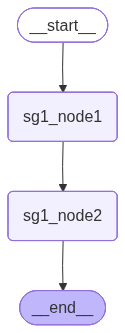

In [7]:
class Sg1State(TypedDict):
    sg1_data: str
    shared_data: str
    next_sg: str

def sg1_node1(state):
    print(f"this is sg1 data: {state.get("sg1_data")}")
    return state

def sg1_node2(state):
    choice = random.choice(["sg2", "sg3"])
    print(f"want to go to {choice}")
    return {
            "sg1_data": "new sg1 data",
            "shared_data": "new sg1 shared data",
            "next_sg": choice
        }

sg1_builder = StateGraph(Sg1State)
sg1_builder.add_node("sg1_node1", sg1_node1)
sg1_builder.add_node("sg1_node2", sg1_node2)

sg1_builder.add_edge(START, "sg1_node1")
sg1_builder.add_edge("sg1_node1", "sg1_node2")
sg1_builder.add_edge("sg1_node2", END)
memory_sg1 = InMemorySaver()
sg1 = sg1_builder.compile(checkpointer=memory_sg1)
display(Image(sg1.get_graph().draw_mermaid_png()))

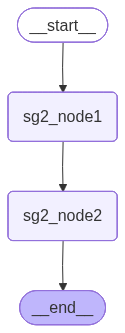

In [8]:
class Sg2State(TypedDict):
    sg2_data: str
    shared_data: str
    next_sg: str

def sg2_node1(state):
    print(f"this is sg2 data: {state.get("sg2_data")}")
    return state

def sg2_node2(state):
    choice = random.choice(["sg1", "sg3"])
    print(f"want to go to {choice}")
    return {
            "sg2_data": "new sg2 data",
            "shared_data": "new sg2 shared data",
            "next_sg": choice
        }

sg2_builder = StateGraph(Sg2State)
sg2_builder.add_node("sg2_node1", sg2_node1)
sg2_builder.add_node("sg2_node2", sg2_node2)

sg2_builder.add_edge(START, "sg2_node1")
sg2_builder.add_edge("sg2_node1", "sg2_node2")
sg2_builder.add_edge("sg2_node2", END)
sg2 = sg2_builder.compile()
display(Image(sg2.get_graph().draw_mermaid_png()))

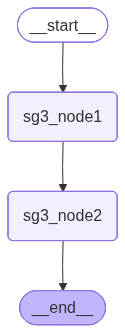

In [9]:
class Sg3State(TypedDict):
    sg3_data: str
    shared_data: str
    next_sg: str

def sg3_node1(state):
    print(f"this is sg3 data: {state.get("sg3_data")}")
    return state

def sg3_node2(state):
    choice = random.choice(["sg1", "sg2", END])
    print(f"want to go to {choice}")
    return {
            "sg3_data": "new sg3 data",
            "shared_data": "new sg3 shared data",
            "next_sg": choice
        }

sg3_builder = StateGraph(Sg3State)
sg3_builder.add_node("sg3_node1", sg3_node1)
sg3_builder.add_node("sg3_node2", sg3_node2)

sg3_builder.add_edge(START, "sg3_node1")
sg3_builder.add_edge("sg3_node1", "sg3_node2")
sg3_builder.add_edge("sg3_node2", END)
sg3 = sg3_builder.compile()
display(Image(sg3.get_graph().draw_mermaid_png()))

In [10]:
def router_sg1(state) -> Literal["sg2", "sg3"]:
    return state["next_sg"]

def router_sg2(state) -> Literal["sg1", "sg3"]:
    return state["next_sg"]

def router_sg3(state) -> Literal["sg2", "sg1", END]:
    return state["next_sg"]

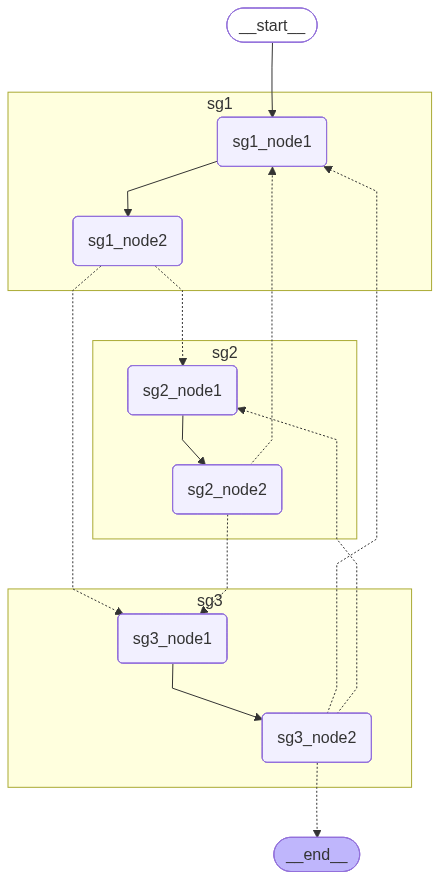

In [17]:
class ParentState(TypedDict):
    sg1_data: str
    shared_data: str
    next_sg: str

builder = StateGraph(ParentState)
builder.add_node("sg1", sg1)
builder.add_node("sg2", sg2)
builder.add_node("sg3", sg3)

builder.add_edge(START, "sg1")
builder.add_conditional_edges("sg1", router_sg1)
builder.add_conditional_edges("sg2", router_sg2)
builder.add_conditional_edges("sg3", router_sg3)

from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

parent = builder.compile(checkpointer=memory)
display(Image(parent.get_graph(xray=1).draw_mermaid_png()))

In [18]:
parent.invoke({"sg1_data": "initial sg1_data", "sg2_data": "initial sg2_data", "sg3_data": "initial sg3_data", "shared_data": "initial shared data"}, {"configurable": {"thread_id": "1"}})

this is sg1 data: initial sg1_data
want to go to sg2
this is sg2 data: None
want to go to sg3
this is sg3 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg3
this is sg3 data: None
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg3
this is sg3 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg2
this is sg2 data: None
want to go to sg3
this is sg3 data: None
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: new sg1 data
want to go to sg3
this is sg3 data: None
want to go to __end__


{'sg1_data': 'new sg1 data',
 'shared_data': 'new sg3 shared data',
 'next_sg': '__end__'}

only stuff common to both subgraph and parent graph remains saved

In [122]:
parent.get_state({"configurable": {"thread_id": "1"}}, subgraphs=True)

StateSnapshot(values={'shared_data': 'new sg3 shared data', 'next_sg': '__end__'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09fdb1-323b-6c66-800c-40affc593a3b'}}, metadata={'source': 'loop', 'step': 12, 'parents': {}}, created_at='2025-10-02T21:59:31.624853+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09fdb1-3231-6e92-800b-58c970884fbb'}}, tasks=(), interrupts=())

In [ ]:
!pip install -q langgraph_swarm

In [7]:
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_swarm, create_handoff_tool

llm_qwen = ChatGroq(model="qwen/qwen3-32b")

def book_flight(frm: str, to: str):
    """
    helps book flight
    arguments:
    frm: from airport code
    to: to airport code
    """
    print(f"flight booked from {frm} to {to}")

def book_hotel(city: str, date: str):
    """
    helps book hotel
    arguments:
    city: city name
    date: date of stay
    """
    print(f"hotel booked in {city} on {date}")

transfer_to_hotel_assistant = create_handoff_tool(
    agent_name="hotel_assistant",
    description="Transfer user to the hotel-booking assistant.",
)
transfer_to_flight_assistant = create_handoff_tool(
    agent_name="flight_assistant",
    description="Transfer user to the flight-booking assistant.",
)

flight_assistant = create_react_agent(
    model=llm_qwen,
    tools=[book_flight, transfer_to_hotel_assistant],
    prompt="You are a flight booking assistant",
    name="flight_assistant"
)
hotel_assistant = create_react_agent(
    model=llm_qwen,
    tools=[book_hotel, transfer_to_flight_assistant],
    prompt="You are a hotel booking assistant",
    name="hotel_assistant"
)

swarm = create_swarm(
    agents=[flight_assistant, hotel_assistant],
    default_active_agent="flight_assistant"
).compile()

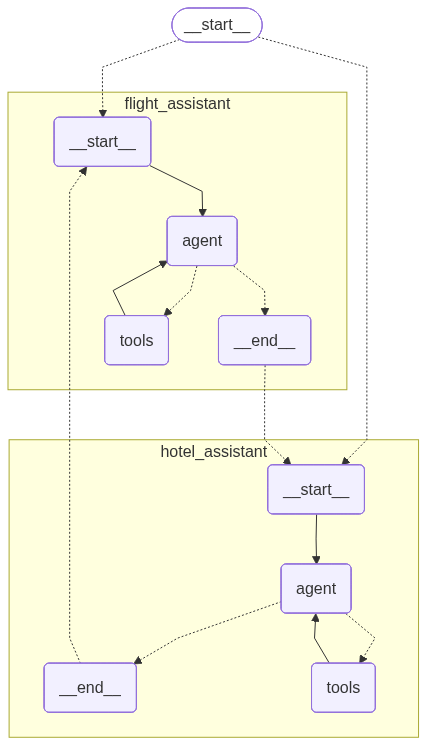

In [17]:
display(Image(swarm.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
for chunk in swarm.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "book a flight from BOS to JFK and a stay at McKittrick Hotel"
            }
        ]
    }
):
    print(chunk)
    print("\n")